In [1]:
!pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import ipywidgets as widgets
from IPython.display import display, Math, Latex
import numpy as np
import matplotlib.pyplot as plt

from widgets import *

plt.rcParams.update({
    'font.size': 16,          # Global text size
    'font.family': 'sans-serif', # Use 'serif' for math look, 'sans-serif' for clean look
    'axes.titlesize': 18,     # Title size
    'axes.labelsize': 16,     # x and y label size
    'xtick.labelsize': 14,    # Tick numbers size
    'ytick.labelsize': 14,
    'legend.fontsize': 16
})

# 1D Neural Networks

In [3]:
relu_widget = ReLU_NNWidget()
relu_widget.display()

Output()

## Challenge: Can you create the "hat" function from the image below?

<img src="relu_network_plot.png" width="60%"/>

## Recipe: How to create any piecewise linear function with n breakpoints

<div style="display: flex; flex-direction: row;">
<div style="flex: 50%; padding-right: 10px;">

### The recipe
#### 1. Count how many segments you have
</div>
<div style="flex: 50%; padding-left: 10px;">

### Applied to the hat function
We have four segments (from left to right):
1. we start with a flat line
2. then go upwards
3. go downwards
4. and end with a flat line again
</div>
</div>

<div style="display: flex; flex-direction: row;">
<div style="flex: 50%; padding-right: 10px;">

#### 2. Determine the slope of each segment
</div>
<div style="flex: 50%; padding-left: 10px;">

Looking at the plot, we get:
1. slope = 0
2. slope = 1
3. slope = -1
4. slope = 0
</div>
</div>

<div style="display: flex; flex-direction: row;">
<div style="flex: 50%; padding-right: 10px;">

#### 3. Match the leftmost slope
To realise a straight line, we need to ReLU neurons:
$$
\text{NN}(x) = \text{ReLU}(k_1 x + d_1) - \text{ReLU}(-k_1 x - d_1)
$$

</div>
<div style="flex: 50%; padding-left: 10px;">

Since our line is the zero line, it is even easier:
$$
\text{NN}(x) = \text{ReLU}(0 \cdot x + 0) = 0
$$
</div>
</div>

<div style="display: flex; flex-direction: row;">
<div style="flex: 50%; padding-right: 10px;">

#### 3. Match the next segments
We continue with this step from left to right until we have realised all our segments.

We add another neuron where the slope is the difference of the slope of the current segment minus the slope of the previous segment.

But it is actually easier to multiply that from outside the ReLU function (but inside works as well). So we set $k=1$ and $a$ to the slope.

For the offset $d$, we use the location of the breakpoint.

This neuron is then added to our function.
</div>
<div style="flex: 50%; padding-left: 10px;">

The next segment has slope 1, the previous slope was 0 so we set $a_2=1-0=1$ and $k_2=1$. The breakpoint is at $x=-1$ so we set $d_2=-(-1)=1$.

We add it to our previous function to get
$$
\text{NN}(x) = 0 + 1 \cdot \text{ReLU}(x+1)
$$

The next segment has slope -1, the previous slope was 1 so we set $a_3=-1-1=-2$ and $k_3=1$. The breakpoint is at $x=0$ so we set $d_3=0$.

We add it to our previous function to get
$$
\text{NN}(x) = 0 + 1 \cdot \text{ReLU}(x+1) -2 \text{ReLU}(x)
$$

The last segment has slope 0, the previous slope was -1 so we set $a_4=-1-0=-1$ and $k_4=1$. The breakpoint is at $x=1$ so we set $d_4=-1$.

We add it to our previous function to get
$$
\text{NN}(x) = 0 + 1 \cdot \text{ReLU}(x+1) -2 \text{ReLU}(x) -1 \text{ReLU}(x)
$$

</div>
</div>

# 2D Neural Networks

In [4]:
!pip install scikit-image

Defaulting to user installation because normal site-packages is not writeable


In [5]:
from helper import *

### Fit a network to your own image

1. Upload some picture in PNG format
2. Replace `FILENAME = "geometric.png"` with your filename
3. Execute the code cells below

If training takes too long, lower `MAX_RESOLUTION = 500` (the amount of pixels for the largest dimension).

You can try with a different amount of neurons by setting `NEURONS = 512` to a different value, or with more training steps by setting `TRAIN_STEPS = 1000` to a higher value.

In [6]:
FILENAME = "geometric.png"

MAX_RESOLUTION = 500

TRAIN_STEPS = 100

NEURONS = 256

In [7]:
my_custom_image = plt.imread(FILENAME)

if my_custom_image.shape[-1] == 4:
    my_custom_image = my_custom_image[:, :, :3]

H,W,C = my_custom_image.shape
max_dim = max(H, W)
if max_dim > MAX_RESOLUTION:
    resize_factor = MAX_RESOLUTION / max_dim
    Hn = int(H * resize_factor)
    Wn = int(W * resize_factor)
    resized_img = resize(my_custom_image, (Hn, Wn), anti_aliasing=True)
    print(f"Resized image from {H}x{W} to {Hn}x{Wn}")

Resized image from 1536x2816 to 272x500


Training with 256 neurons on cuda...
Epoch 0/100 | Loss: 0.03403


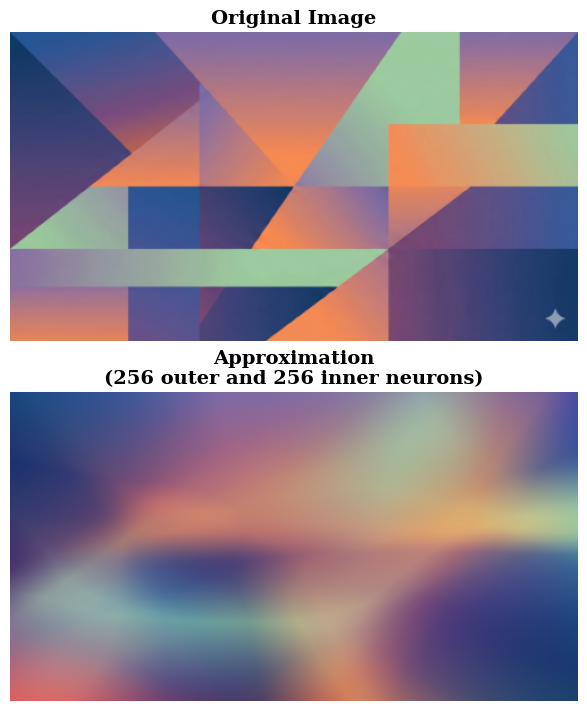

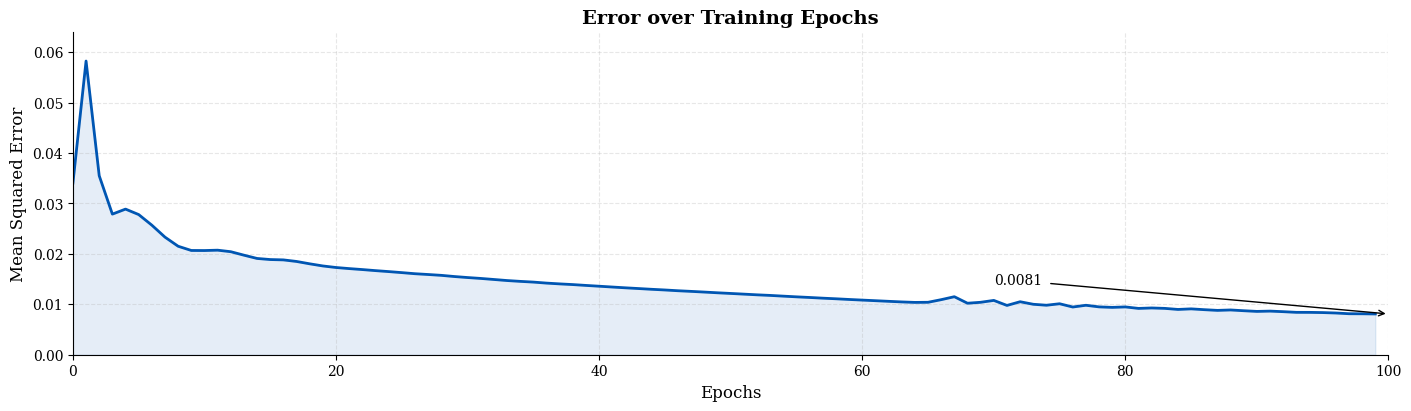

In [8]:
fit_image(n_neurons=NEURONS, epochs=TRAIN_STEPS, image_source=resized_img, activation=nn.ReLU())